# Descriptive analysis and prediction of Student Performance dataset from Kaggle


The dataset was selected from Kaggle. It contains multiple predictor variables such as hours studied, previous scores, extracurricular activities, sleep hours, sample question papers practiced. It has a target/outcome variable **performance index**. The performance index represents the student's academic performance. The index ranges from 10 to 100, with higher values indicating better performance.\
Link for the dataset: https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression

**1. Loading the dataset:**

In [20]:
import pandas as pd
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


**2. Importing all the libraries we need:**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("libraries imported successfully.")

libraries imported successfully.


**3. Dataset information:**

In [22]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (10000, 6)

Column Names:
Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB

Missing Values:
Hours Studied                       0
Previous Scores                 

**4. Removing the 127 duplicate rows**

In [23]:
df = df.drop_duplicates()
print("Number of duplicate rows:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Dataset shape after removing duplicates: (9873, 6)


In [24]:
df.describe() # general summary of all the columns

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,6.531652,4.583004,55.216651
std,2.589081,17.325601,1.697683,2.867202,19.208570
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


**5. Central values:**

In [25]:
print("Mean:")
print(df.mean(numeric_only = True),"\n") # since extracurricular activities has yes/no values
print("Median:")
print(df.median(numeric_only = True),"\n")
print("Mode:")
print(df.mode(numeric_only = True),"\n")

Mean:
Hours Studied                        4.992100
Previous Scores                     69.441102
Sleep Hours                          6.531652
Sample Question Papers Practiced     4.583004
Performance Index                   55.216651
dtype: float64 

Median:
Hours Studied                        5.0
Previous Scores                     69.0
Sleep Hours                          7.0
Sample Question Papers Practiced     5.0
Performance Index                   55.0
dtype: float64 

Mode:
   Hours Studied  Previous Scores  Sleep Hours  \
0              1               54            8   

   Sample Question Papers Practiced  Performance Index  
0                                 6               67.0   



**6. Measures of dispersion:**

In [26]:
print("Measures of dispersion for performance index")
print("Range : ", df["Performance Index"].max() - df["Performance Index"].min(),
      "\nVariance : ", df["Performance Index"].var(),
      "\nStandard deviation : ", df["Performance Index"].std(),
      "\nIQR : ", df["Performance Index"].quantile(0.75) - df["Performance Index"].quantile(0.25))


Measures of dispersion for performance index
Range :  90.0 
Variance :  368.9691635431246 
Standard deviation :  19.208570054616885 
IQR :  30.0


**7. Creating a frequency distribution and plotting a bar chart**

Performance Index
10-20      265
21-30      837
31-40     1428
41-50     1672
51-60     1602
61-70     1601
71-80     1412
81-90      850
91-100     206
Name: count, dtype: int64


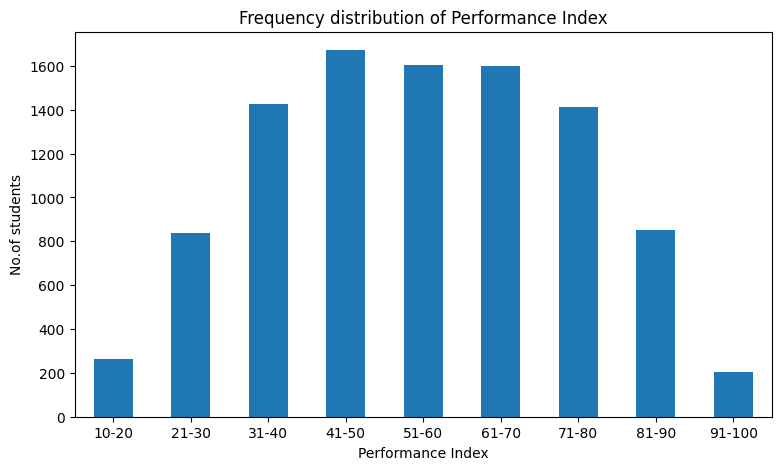

In [27]:
bins = [10,20,30,40,50,60,70,80,90,100]
labels = [
    "10-20",
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "71-80",
    "81-90",
    "91-100"
]
frequency = pd.cut(
    df["Performance Index"],
    bins = bins,
    labels = labels,
    include_lowest=True
).value_counts().sort_index()
print(frequency)

plt.figure(figsize = (9,5))
frequency.plot(kind = 'bar')
plt.title("Frequency distribution of Performance Index")
plt.xlabel("Performance Index")
plt.ylabel("No.of students")
plt.xticks(rotation=0)
plt.show()

**8. Histogram**

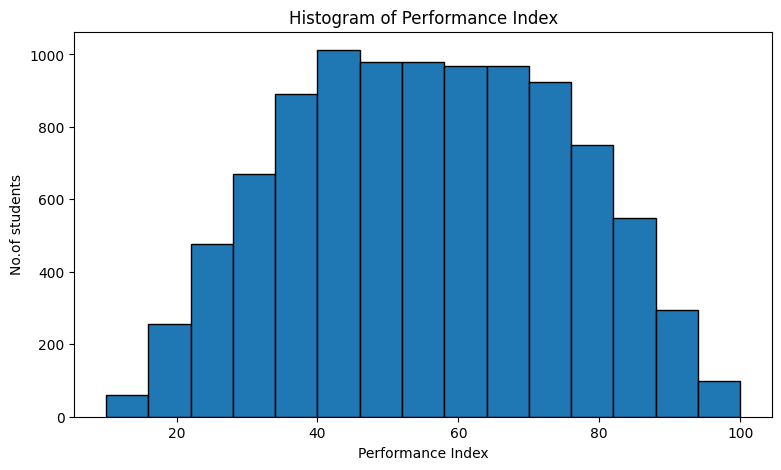

In [28]:
plt.figure(figsize = (9,5))
plt.hist(
    df["Performance Index"],
    bins = 15,
    edgecolor = 'black',
)
plt.title("Histogram of Performance Index")
plt.xlabel("Performance Index")
plt.ylabel("No.of students")
plt.show()

**9. Skewness & Kurtosis**

In [29]:
skewness = df["Performance Index"].skew()
kurtosis = df['Performance Index'].kurt()
print("skewness: ",skewness,"\nkurtosis: ",kurtosis)
if(skewness>0):
  print("Performance Index is positively skewed")
elif(skewness<0):
  print("performance index is negatively skewed")
else:
  print("there is no skewness (0-skewed)")
if(kurtosis>0):
  print("Performance Index is leptokurtic")
elif(kurtosis<0):
  print("performance index is platikurtic")
else:
  print("Performance index is similar to a normal distribution")


skewness:  -0.00041186196091178305 
kurtosis:  -0.8601253774528677
performance index is negatively skewed
performance index is platikurtic


This means most values are concentrated to the higher end and there are some extreme values to the lower end. Platikurtic means there are less outliers.

**10. Pearson Correlation Matrix**

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.010676,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.007975,0.008719,0.915135
Sleep Hours,0.002131,0.007975,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.050352,0.043436,1.000000


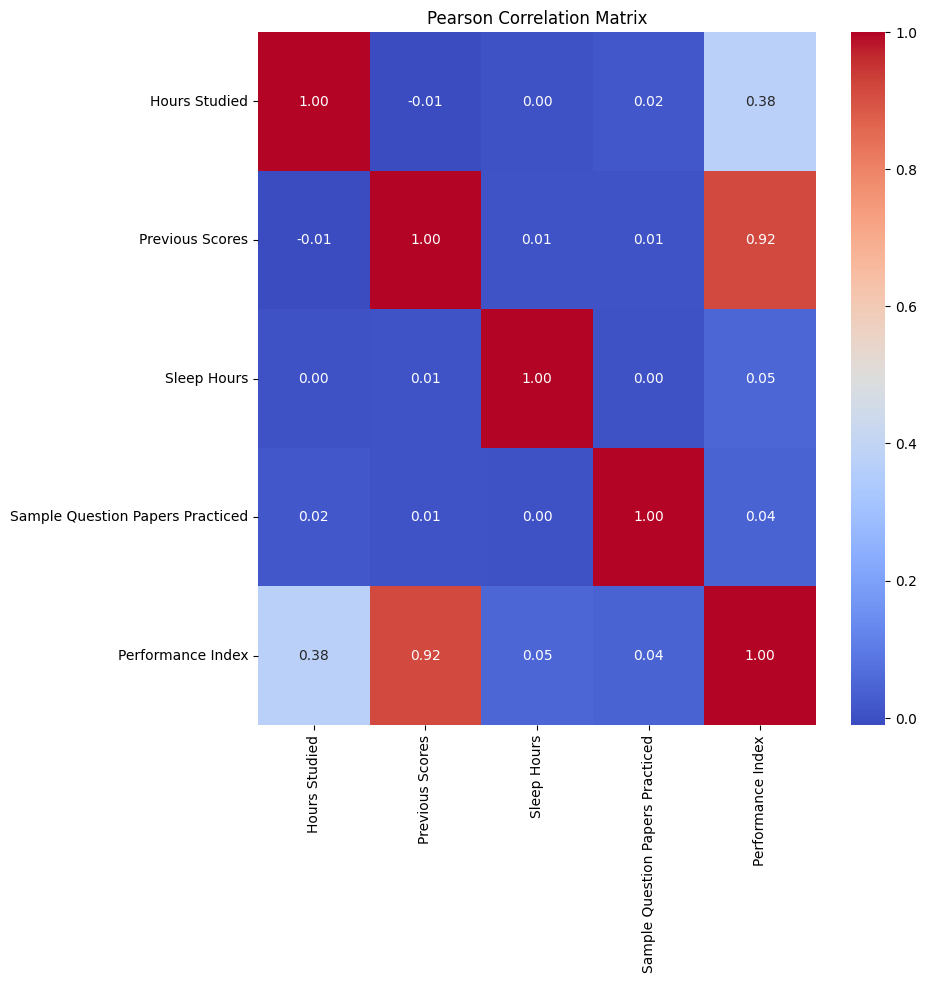

In [30]:
variables = [
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced",
    "Performance Index"
]
correlation_matrix = df[variables].corr(method = 'pearson')
display(correlation_matrix)

plt.figure(figsize = (9,9))
sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = "coolwarm",
    fmt=".2f"
)
plt.title("Pearson Correlation Matrix")
plt.show()


**11. Pearson correlation between Sleep Hours and Performance Index**

In [31]:
pearson_correlation = df['Sleep Hours'].corr(df['Performance Index'] , method = 'pearson')
print("The pearson correlation between sleep hours and performance index is",round(pearson_correlation,5))

The pearson correlation between sleep hours and performance index is 0.05035


Plotting **previous scores** vs **performance index**

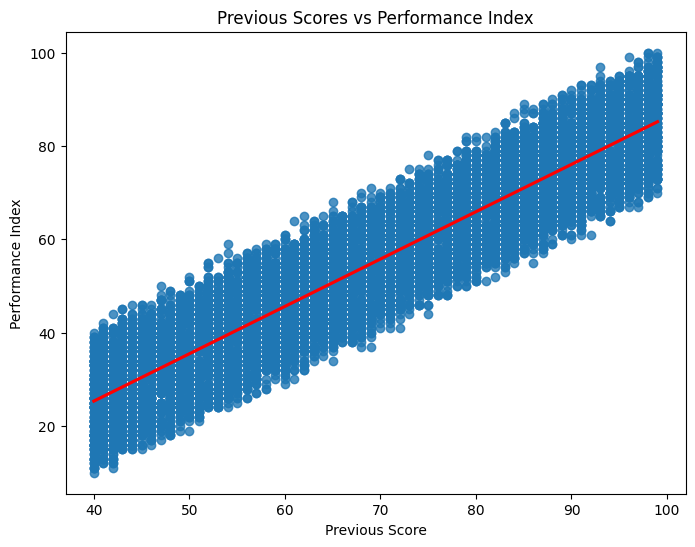

In [32]:
plt.figure(figsize = (8,6))
sns.regplot(
    x="Previous Scores",
    y="Performance Index",
    data = df,
    line_kws={"color": "red"}
)
plt.title("Previous Scores vs Performance Index")
plt.xlabel("Previous Score")
plt.ylabel("Performance Index")
plt.show()

**13. Covariance**

In [33]:
covariance_matrix = df[['Sleep Hours','Previous Scores','Hours Studied','Performance Index']].cov()
display(covariance_matrix)

,Sleep Hours,Previous Scores,Hours Studied,Performance Index
Sleep Hours,2.882127,0.234568,0.009367,1.641997
Previous Scores,0.234568,300.176459,-0.478889,304.556978
Hours Studied,0.009367,-0.478889,6.703341,18.666217
Performance Index,1.641997,304.556978,18.666217,368.969164


**14. Linear Regression**

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
features = [
    "Sleep Hours",
    "Previous Scores",
    "Hours Studied",
    "Sample Question Papers Practiced",
]
x = df[features]
y = df["Performance Index"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)
model = LinearRegression()
model.fit(x_train, y_train)
coef = pd.DataFrame({
    "variable ": features,
    " regression coefficient": model.coef_
})
display(coef)
# each coef is how much the predicted value changes when the feature value increases by 1
print("the intercept: ",model.intercept_) # performance index value if all the features are set to 0
predictions = model.predict(x_test)
print("Regression model trained.")

,variable,regression coefficient
0,Sleep Hours,0.467828
1,Previous Scores,1.018562
2,Hours Studied,2.851437
3,Sample Question Papers Practiced,0.190424


the intercept:  -33.687511008025254
Regression model trained.


**15. Model Evaluation**

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mean_abs_error = mean_absolute_error(y_test,predictions)
# avg of absolute values of errors of predictions is mae
root_mean_sq_error = np.sqrt(mean_squared_error(y_test,predictions))
# errors are squared, root of the avg of the squares is rmse
r2 = r2_score(y_test,predictions)
# r^2 is coef of determination, tells us what percentage of the variation in the data is explained by the model
print("Mean Absolute Error :", round(mean_abs_error, 2))
print("Root Mean Squared Error:", round(root_mean_sq_error, 2))
print("R²(coef of determination):", round(r2, 3))

Mean Absolute Error : 1.68
Root Mean Squared Error: 2.11
R²(coef of determination): 0.988


**16. Scatterplot for actual vs predicted values**

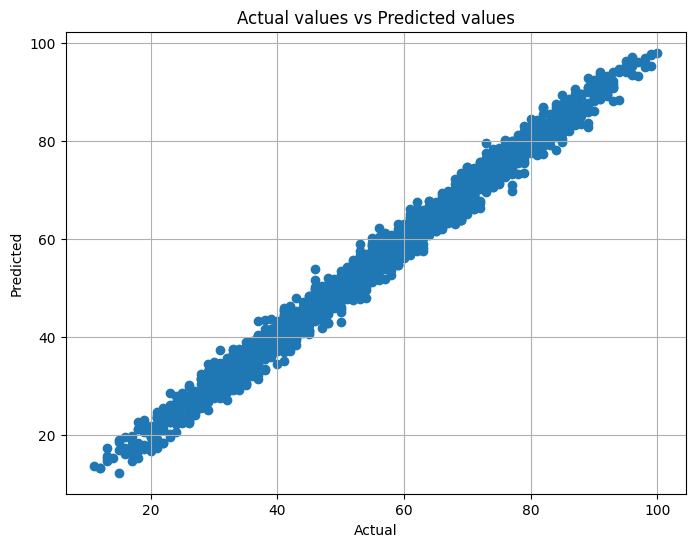

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,predictions)
plt.title("Actual values vs Predicted values")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.show()

**17. Predicting the Performance Index for a new student**

In [37]:
import ipywidgets as widgets # library to create buttons & other interactive elements
sleep_hours = widgets.FloatText(
    description ="Hours Slept:"
)

previous_scores = widgets.FloatText(
    description="Previous Scores:"
)

hours_studied = widgets.FloatText(
    description="Hours Studied:"
)

papers_practiced = widgets.IntText(
    description="Papers Practiced:"
)


In [38]:
predict_button = widgets.Button(
    description = "Predict Performance Index"
)
output = widgets.Output()
def predict_when_clicked(button):
    new_student = pd.DataFrame(
        [[sleep_hours.value, previous_scores.value, hours_studied.value, papers_practiced.value]],
        columns=features
    )
    prediction = model.predict(new_student)[0]
    with output:
      output.clear_output()
      print(f"predicted performance index: {prediction}")

predict_button.on_click(predict_when_clicked)

display(
    sleep_hours,
    previous_scores,
    hours_studied,
    papers_practiced,
    predict_button,
    output
)

FloatText(value=0.0, description='Hours Slept:')

FloatText(value=0.0, description='Previous Scores:')

FloatText(value=0.0, description='Hours Studied:')

IntText(value=0, description='Papers Practiced:')

Button(description='Predict Performance Index', style=ButtonStyle())

Output()